<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"></center> </p>

<hr style="border-width:2px;border-color:#ff6745">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Features Engineering </h2></center>
<hr style="border-width:2px;border-color:#ff6745">


## Objectif du notebook

Ce notebook prépare les données qui seront utilisées ensuite pour la prédiction de la variabilité photovoltaïque.

L'objectif principal est de construire des variables explicatives propres, cohérentes et sans fuite de données, afin de prédire la variation future de la production solaire.

La variable cible est définie comme :

$$
target(t) = |TCH_{solaire}(t+1) - TCH_{solaire}(t)|
$$

Autrement dit, on cherche à prédire la variation absolue du taux de charge solaire entre l'instant actuel `t` et l'instant suivant `t+1`.

Comme les données sont en pas de temps de 30 minutes, la cible représente donc la variabilité solaire sur les 30 prochaines minutes.

## Stratégie générale

Le notebook suit une progression volontairement progressive :

1. charger les données météorologiques, radiatives et de production;
2. enrichir les données avec des encodages cycliques adaptés aux variables périodiques;
3. figer les ensembles `train`, `valid` et `test` pour éviter toute fuite temporelle;
4. créer des variables dérivées à partir des informations disponibles au temps présent ou dans le passé;
5. construire une première version des jeux de données aux 5 points représentatifs;
6. agréger ensuite les variables au niveau régional;
7. ajouter des indicateurs régionaux complémentaires, comme le CSI et le ratio production/irradiance;
8. définir la cible finale et sauvegarder les fichiers prêts pour la modélisation.

## Règle importante

Toutes les variables explicatives doivent utiliser uniquement l'information disponible à l'instant `t` ou avant.

On ne doit jamais utiliser une information future pour construire une variable explicative, car cela créerait une fuite de données et donnerait une performance artificiellement optimiste.

# I - Chargement des données PACA

La première étape consiste à charger le fichier **`raw_2020_2025.csv`**, qui regroupe les données météorologiques, radiatives et énergétiques utilisées dans ce projet pour la région PACA, avec une résolution temporelle de **30 minutes**.

Les variables disponibles dans ce jeu de données comprennent notamment :

- **`azimuth`** : azimut solaire, exprimé en degrés, indiquant la direction horizontale du soleil;
- **`altitude`** : altitude solaire, représentant l'élévation du soleil au-dessus de l'horizon;
- **`temperature`** : température de l'air;
- **`GHI`** (*Global Horizontal Irradiance*) : irradiance globale reçue sur un plan horizontal;
- **`BHI`** (*Beam Horizontal Irradiance*) : composante directe projetée sur le plan horizontal;
- **`DHI`** (*Diffuse Horizontal Irradiance*) : composante diffuse reçue sur un plan horizontal;
- **`BNI`** (*Beam Normal Irradiance*) : irradiance directe normale;
- **`vitesse_vent`** : vitesse du vent;
- **`nebulosite`** : fraction de couverture nuageuse;
- **`humidite`** : humidité de l'air;
- **`clear_sky_ghi`**, **`clear_sky_bhi`**, **`clear_sky_dhi`**, **`clear_sky_bni`** : irradiances théoriques en conditions de ciel clair;
- **`toa`** (*Top Of Atmosphere*) : rayonnement solaire incident au sommet de l'atmosphère.

Cette étape sert donc à poser la base du notebook : on vérifie les chemins, on charge les fichiers, puis on identifie les variables disponibles pour les communes sélectionnées.


Nous commençons par importer les bibliothèques nécessaires à la manipulation des données, aux calculs numériques et aux visualisations.

In [1]:
# Gestion des chemins
from pathlib import Path

# Données et calculs
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analyse des variables
from sklearn.feature_selection import VarianceThreshold

# Affichage des graphiques dans le notebook
%matplotlib inline

On définit maintenant les chemins vers les fichiers d'entrée et de sortie.  
Ces chemins permettent de garder une organisation claire entre les données brutes, les fichiers temporaires et les jeux de données finaux.


In [2]:
# Chemin vers le répertoire de données d'entrée
input_path = Path('../../data/local_data/input/')

# Chemin vers le répertoire de résultats temporaires
temp_path = Path('../../data/local_data/temp/')

# Chemin vers le répertoire de résultats finaux
output_path = Path('../../data/local_data/output')

# Chemin du dataset de production
input_datasets = output_path / 'raw_2020_2025.csv'

# Chemin du dataset des communes sélectionnées 
communes_path = output_path / 'best_communes_geo_energy.csv'


In [3]:
# On récupère le dataset raw_2020_2025.csv
df = pd.read_csv(
    input_datasets,
    index_col="datetime_utc",
    parse_dates=True
)

# Trier l'index temporel par sécurité
df = df.sort_index()

# Supprimer les éventuels doublons temporels
df = df[~df.index.duplicated(keep="first")]

print("Dimensions du dataset :", df.shape)
print("Date de début :", df.index.min())
print("Date de fin   :", df.index.max())

# Ainsi que les données concernant les cinq points significatifs
df_communes = pd.read_csv(communes_path)


Dimensions du dataset : (105170, 84)
Date de début : 2019-12-31 23:00:00+00:00
Date de fin   : 2025-12-30 23:30:00+00:00


In [4]:
# Extraction de la liste des préfixes des points d'intérêts :
villes = list(df_communes['prefix'])
print("Préfixes des points d'intérêts :", villes)

# Extraction de la base du nom des variables appartenant aux points d'intérêts
var_5pts = []
# Comme tous les points d'intérêts ont exactement les même colonnes les concernant,
# on fait une recherche des noms concernant la ville de Bras (villes[0])
for col in df.columns : # Pour toutes les colonnes de X
    if col[:3] == villes[0]: # On cherche celles commencant par le préfixe 'bra'
        var_5pts.append(col[4:]) # On ajoute le nom de la colonne (moins le préfixe de la ville)
        # On a ici tiré parti du fait que tous les préfixes sont codés sur 3 lettres    
print("\nVariables disponible pour chaque points d'intérets :")
for var in var_5pts:
    print(f'\t{var}')
    

Préfixes des points d'intérêts : ['cru', 'sel', 'svt', 'bra', 'eyg']

Variables disponible pour chaque points d'intérets :
	altitude
	azimuth
	bhi
	bni
	clear_sky_bhi
	clear_sky_bni
	clear_sky_dhi
	clear_sky_ghi
	dhi
	ghi
	humidite
	nebulosite
	reliability
	temperature
	toa
	vitesse_vent


# II - Encodage temporel

Une fois les données chargées, la première famille de variables à traiter concerne le temps.  
La variabilité photovoltaïque dépend fortement de phénomènes cycliques, notamment l'alternance jour/nuit et la saisonnalité.

Utiliser directement l'heure ou le jour de l'année comme des variables numériques simples peut introduire des discontinuités artificielles : par exemple, 23 h et 0 h sont très proches dans le temps, mais très éloignées numériquement. De même, le 31 décembre et le 1er janvier représentent deux dates voisines dans le cycle annuel.

Pour préserver cette continuité, on utilise un [**encodage cyclique sinusoïdal**](https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/).

## A - Encodage de l'heure de la journée et du jour de l'année

Pour l'heure de la journée, on définit :

$$
\text{sin\_hour}(t) = \sin\left( \frac{2\pi \cdot \text{hour}(t)}{24} \right), \quad
\text{cos\_hour}(t) = \cos\left( \frac{2\pi \cdot \text{hour}(t)}{24} \right)
$$

où $\text{hour}(t)$ est une variable continue qui combine les heures et les minutes.

Pour le jour de l'année, on définit de manière analogue :

$$
\text{sin\_doy}(t) = \sin\left( \frac{2\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right), \quad
\text{cos\_doy}(t) = \cos\left( \frac{2\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right)
$$

où $N_{\text{jours}} = 365$ ou $366$, selon que l'année est bissextile ou non.

Cet encodage respecte la périodicité solaire et donne au modèle une représentation plus naturelle du rythme journalier et saisonnier.


In [5]:
# Encodage cyclique de l'heure
hour = df.index.hour + df.index.minute / 60
df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour / 24) 

# Encodage cyclique du jour de l'année (avec années bissextiles)
doy = df.index.dayofyear - 1
nb_jour_annee = np.where(df.index.is_leap_year, 366, 365)
df['sin_doy'] = np.sin(2 * np.pi * doy / nb_jour_annee)
df['cos_doy'] = np.cos(2 * np.pi * doy / nb_jour_annee)

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_reliability,svt_temperature,svt_toa,svt_vitesse_vent,tch_solaire,tco_solaire,sin_hour,cos_hour,sin_doy,cos_doy
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,9.30,0.0,1.190,0.0,0.0,-0.258819,0.965926,-0.017213,0.999852
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,9.48,0.0,1.075,0.0,0.0,-0.130526,0.991445,-0.017213,0.999852
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,9.66,0.0,0.960,0.0,0.0,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,9.72,0.0,0.850,0.0,0.0,0.130526,0.991445,0.000000,1.000000
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,9.78,0.0,0.740,0.0,0.0,0.258819,0.965926,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,-56.569891,297.046679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,6.11,0.0,6.485,0.0,0.0,-0.608761,0.793353,-0.034422,0.999407
2025-12-30 22:00:00+00:00,-61.185289,306.991992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,6.14,0.0,6.680,0.0,0.0,-0.500000,0.866025,-0.034422,0.999407
2025-12-30 22:30:00+00:00,-65.154326,319.536559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,6.23,0.0,6.770,0.0,0.0,-0.382683,0.923880,-0.034422,0.999407


Dimensions : (105170, 88)


## B - Visualisation de l'encodage cyclique

Après avoir créé les variables sinus et cosinus, on vérifie visuellement qu'elles se projettent bien sur un cercle unité.  
Cette représentation permet de confirmer que les frontières artificielles, comme minuit ou le changement d'année, sont correctement traitées.

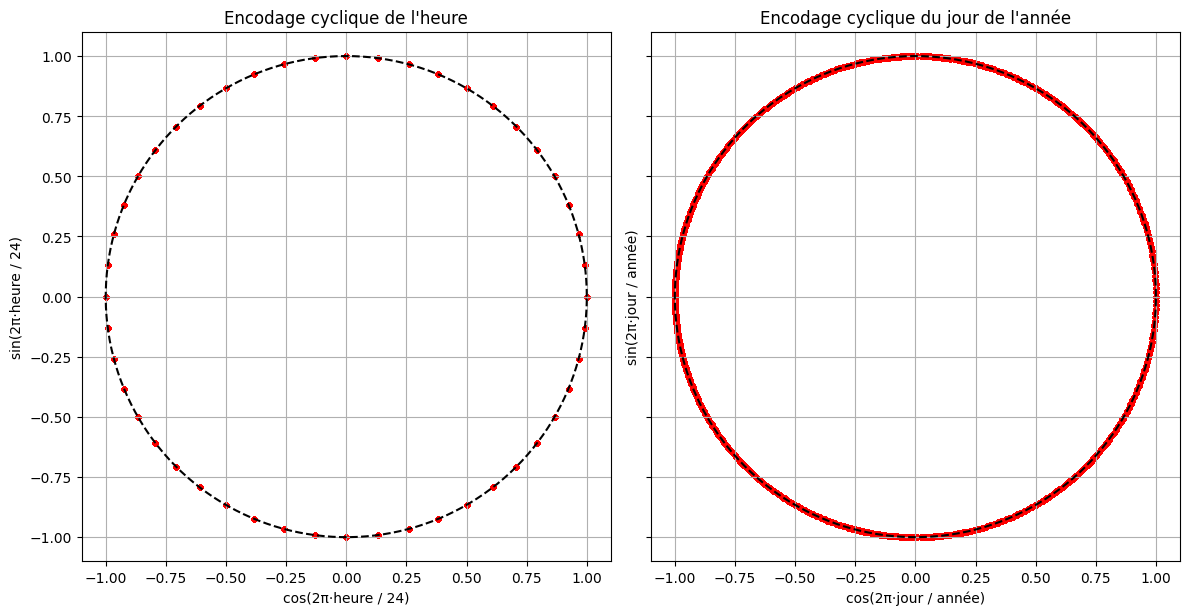

In [6]:
theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# --- Subplot 1 : Encodage cyclique de l'heure ---
ax = axes[0]
ax.scatter(df['cos_hour'], df['sin_hour'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·heure / 24)")
ax.set_ylabel("sin(2π·heure / 24)")
ax.set_title("Encodage cyclique de l'heure")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# --- Subplot 2 : Encodage cyclique du jour de l'année ---
ax = axes[1]
ax.scatter(df['cos_doy'], df['sin_doy'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·jour / année)")
ax.set_ylabel("sin(2π·jour / année)")
ax.set_title("Encodage cyclique du jour de l'année")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
    

Les points rouges sont répartis sur le cercle unité. Cette visualisation confirme que les instants proches dans un cycle restent proches dans l'espace encodé : 23 h et 0 h sont voisins, tout comme le 31 décembre et le 1er janvier.

Après cette vérification géométrique, on examine maintenant l'évolution temporelle des composantes sinus et cosinus afin de vérifier leur continuité sur la journée.


## C - Continuité de l'encodage cyclique

Cette étape complète la visualisation précédente.  
Au lieu d'observer les points sur le cercle unité, on trace les composantes sinus et cosinus au cours du temps pour vérifier qu'elles varient de manière progressive.


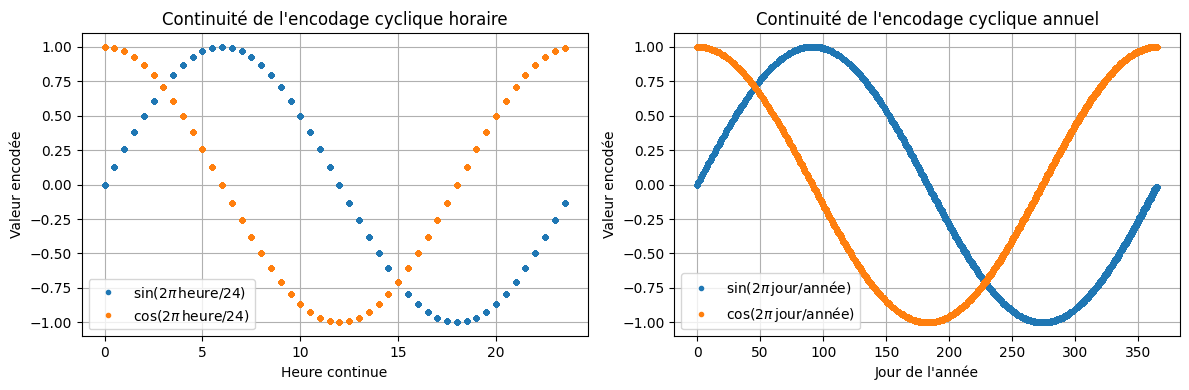

In [7]:
# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df.index.hour + df.index.minute / 60
doy = df.index.dayofyear - 1

plt.figure(figsize=(12, 4))

# --- Plot 1 : Encodage cyclique de l'heure ---
plt.subplot(1, 2, 1)
plt.plot(hour, df['sin_hour'], '.', label=r'$\sin(2\pi\,\mathrm{heure}/24)$')
plt.plot(hour, df['cos_hour'], '.', label=r'$\cos(2\pi\,\mathrm{heure}/24)$')
plt.xlabel("Heure continue")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique horaire")
plt.legend()
plt.grid(True)

# --- Plot 2 : Encodage cyclique du jour de l'année ---
plt.subplot(1, 2, 2)
plt.plot(doy, df['sin_doy'], '.', label=r'$\sin(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.plot(doy, df['cos_doy'], '.', label=r'$\cos(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.xlabel("Jour de l'année")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique annuel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## D - Continuité autour de minuit et du changement d'année

On zoome maintenant sur les zones où un encodage classique serait problématique : le passage de 23 h à 0 h et le passage du 31 décembre au 1er janvier.  
L'objectif est de confirmer que l'encodage cyclique évite bien les ruptures numériques à ces frontières.


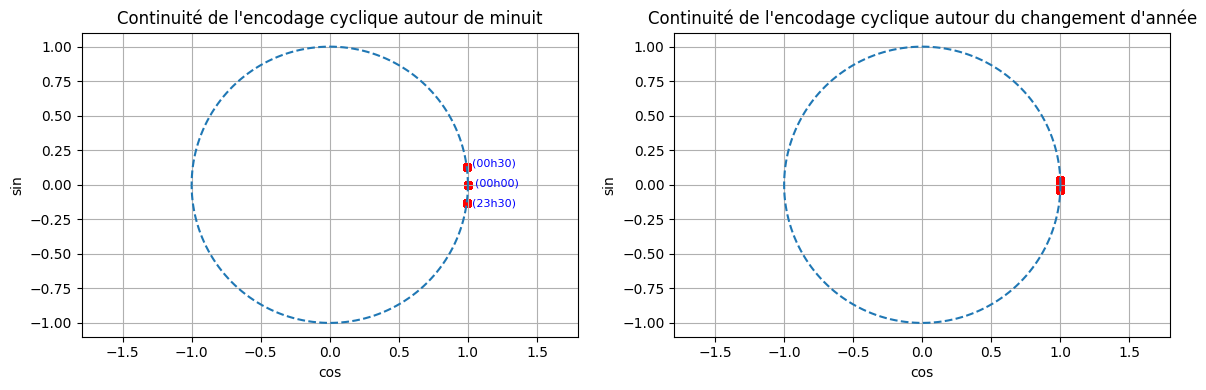

In [8]:
# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df.index.hour + df.index.minute / 60
doy = df.index.dayofyear - 1
year_len = np.where(df.index.is_leap_year, 366, 365)
    
mask_hour = (hour < 1) | (hour > 23)
mask_day  = (doy < 3) | (doy > (year_len - 3))

theta = np.linspace(0, 2*np.pi, 360)

plt.figure(figsize=(12, 4))

# --- Subplot 1 : Continuité autour de minuit ---
plt.subplot(1, 2, 1)
plt.scatter(df.loc[mask_hour, 'cos_hour'],
            df.loc[mask_hour, 'sin_hour'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour de minuit")
plt.grid(True)

plt.text(1.05, -0.01, f"(00h00)", fontsize=8, color='blue')
plt.text(1.03, 0.13, f"(00h30)", fontsize=8, color='blue')
plt.text(1.03, -0.16, f"(23h30)", fontsize=8, color='blue')

# --- Subplot 2 : Continuité autour du changement d'année ---
plt.subplot(1, 2, 2)
plt.scatter(df.loc[mask_day, 'cos_doy'],
            df.loc[mask_day, 'sin_doy'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour du changement d'année")
plt.grid(True)

plt.tight_layout()
plt.show()

# III - Encodage de l'azimut solaire

Après les variables temporelles, on applique le même principe aux variables angulaires.  
L'`azimuth` représente la position horizontale du soleil, avec un angle compris entre 0° et 360°.

Cette variable est également circulaire :

- 0° et 360° correspondent à la même direction;
- 359° est très proche de 1°.

Un encodage numérique classique introduirait donc une discontinuité artificielle.  
Pour éviter ce problème, on transforme l'`azimuth` en deux composantes : un sinus et un cosinus.

Cette transformation préserve la nature cyclique de l'angle et fournit au modèle une représentation plus cohérente de la position horizontale du soleil.


In [9]:
# Copie pour éviter de modifier le DataFrame original
df = df.copy()

for ville in villes:
    col = f"{ville}_azimuth"

    # Vérifie que la colonne existe
    if col not in df.columns:
        continue
    
    # Conversion en radians
    azimuth_rad = np.radians(df[col])
    
    # Encodage cyclique
    df[f"{ville}_azimuth_sin"] = np.sin(azimuth_rad)
    df[f"{ville}_azimuth_cos"] = np.cos(azimuth_rad)
    
    # Suppression de la colonne brute
    df = df.drop(columns=[col])

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)

,bra_altitude,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,...,cru_azimuth_sin,cru_azimuth_cos,sel_azimuth_sin,sel_azimuth_cos,svt_azimuth_sin,svt_azimuth_cos,bra_azimuth_sin,bra_azimuth_cos,eyg_azimuth_sin,eyg_azimuth_cos
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.880,...,-0.413154,0.910661,-0.394993,0.918684,-0.381691,0.924290,-0.418802,0.908078,-0.449858,0.893100
2019-12-31 23:30:00+00:00,-69.500739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84.455,...,-0.107691,0.994184,-0.091708,0.995786,-0.063905,0.997956,-0.105471,0.994422,-0.148646,0.988890
2020-01-01 00:00:00+00:00,-69.141123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.030,...,0.222973,0.974825,0.232271,0.972651,0.269545,0.962988,0.234067,0.972220,0.187966,0.982176
2020-01-01 00:30:00+00:00,-67.054165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.380,...,0.503942,0.863738,0.506813,0.862056,0.542578,0.840006,0.518630,0.854999,0.480522,0.876983
2020-01-01 01:00:00+00:00,-63.656435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.730,...,0.702543,0.711641,0.702084,0.712094,0.729965,0.683485,0.715689,0.698419,0.688929,0.724829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,-56.569891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.740,...,-0.885181,0.465247,-0.877390,0.479779,-0.879374,0.476132,-0.890636,0.454716,-0.896792,0.442452
2025-12-30 22:00:00+00:00,-61.185289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66.590,...,-0.791257,0.611484,-0.779687,0.626169,-0.780788,0.624796,-0.798720,0.601703,-0.809521,0.587092
2025-12-30 22:30:00+00:00,-65.154326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.240,...,-0.640620,0.767858,-0.624920,0.780689,-0.621757,0.783210,-0.648963,0.760820,-0.667887,0.744263


Dimensions : (105170, 93)


# IV - Division du jeu de données en train, validation et test

Une fois les premières variables cycliques ajoutées, on fige le découpage temporel des données.  
Cette étape est importante : les modèles de séries temporelles doivent être évalués sur des périodes futures par rapport aux périodes utilisées pour l'apprentissage.

On utilise donc le découpage suivant :

| Période   | Rôle |
| :--- | :--- |
| 2020–2023 | Entraînement |
| 2024 | Validation |
| 2025 | Test |

Ce découpage permet de construire les variables de manière cohérente tout en conservant un vrai jeu de test final, jamais utilisé pour le choix du modèle.


In [10]:
train = df['2019-12-31':'2023-12-31']
display(train)
train.to_csv(output_path / 'train.csv')

,bra_altitude,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,...,cru_azimuth_sin,cru_azimuth_cos,sel_azimuth_sin,sel_azimuth_cos,svt_azimuth_sin,svt_azimuth_cos,bra_azimuth_sin,bra_azimuth_cos,eyg_azimuth_sin,eyg_azimuth_cos
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.880,...,-0.413154,0.910661,-0.394993,0.918684,-0.381691,0.924290,-0.418802,0.908078,-0.449858,0.893100
2019-12-31 23:30:00+00:00,-69.500739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84.455,...,-0.107691,0.994184,-0.091708,0.995786,-0.063905,0.997956,-0.105471,0.994422,-0.148646,0.988890
2020-01-01 00:00:00+00:00,-69.141123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.030,...,0.222973,0.974825,0.232271,0.972651,0.269545,0.962988,0.234067,0.972220,0.187966,0.982176
2020-01-01 00:30:00+00:00,-67.054165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.380,...,0.503942,0.863738,0.506813,0.862056,0.542578,0.840006,0.518630,0.854999,0.480522,0.876983
2020-01-01 01:00:00+00:00,-63.656435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.730,...,0.702543,0.711641,0.702084,0.712094,0.729965,0.683485,0.715689,0.698419,0.688929,0.724829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00+00:00,-56.510761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.225,...,-0.885335,0.464954,-0.877562,0.479464,-0.879535,0.475834,-0.890775,0.454445,-0.896922,0.442188
2023-12-31 22:00:00+00:00,-61.127320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.560,...,-0.791610,0.611027,-0.780069,0.625693,-0.781164,0.624325,-0.799052,0.601262,-0.809829,0.586667
2023-12-31 22:30:00+00:00,-65.099087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.615,...,-0.641374,0.767229,-0.625713,0.780054,-0.622572,0.782563,-0.649700,0.760190,-0.668566,0.743653


In [11]:
valid = df['2024-01-01':'2024-12-31']
display(valid)
valid.to_csv(output_path / 'valid.csv')

,bra_altitude,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,...,cru_azimuth_sin,cru_azimuth_cos,sel_azimuth_sin,sel_azimuth_cos,svt_azimuth_sin,svt_azimuth_cos,bra_azimuth_sin,bra_azimuth_cos,eyg_azimuth_sin,eyg_azimuth_cos
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,-69.141088,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95.680,...,0.222902,0.974841,0.232202,0.972668,0.269474,0.963008,0.233995,0.972238,0.187893,0.982189
2024-01-01 00:30:00+00:00,-67.054481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94.865,...,0.503885,0.863771,0.506758,0.862089,0.542523,0.840041,0.518573,0.855033,0.480463,0.877015
2024-01-01 01:00:00+00:00,-63.657001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94.050,...,0.702504,0.711680,0.702045,0.712132,0.729928,0.683524,0.715651,0.698458,0.688888,0.724867
2024-01-01 01:30:00+00:00,-59.396982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.455,...,0.830036,0.557710,0.828636,0.559788,0.848034,0.529942,0.839809,0.542882,0.822440,0.568852
2024-01-01 02:00:00+00:00,-54.603773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,92.860,...,0.908830,0.417166,0.907554,0.419935,0.920110,0.391660,0.915354,0.402650,0.904545,0.426378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:30:00+00:00,-56.408485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85.190,...,-0.885629,0.464393,-0.877889,0.478865,-0.879843,0.475264,-0.891042,0.453921,-0.897174,0.441676
2024-12-31 22:00:00+00:00,-61.027236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.100,...,-0.792260,0.610183,-0.780771,0.624818,-0.781858,0.623456,-0.799667,0.600444,-0.810400,0.585876
2024-12-31 22:30:00+00:00,-65.003985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.820,...,-0.642731,0.766092,-0.627137,0.778909,-0.624036,0.781395,-0.651031,0.759051,-0.669793,0.742548


In [12]:
test = df['2025-01-01':'2025-12-31']
display(test)
test.to_csv(output_path / 'test.csv')

,bra_altitude,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,...,cru_azimuth_sin,cru_azimuth_cos,sel_azimuth_sin,sel_azimuth_cos,svt_azimuth_sin,svt_azimuth_cos,bra_azimuth_sin,bra_azimuth_cos,eyg_azimuth_sin,eyg_azimuth_cos
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,-69.097348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.010,...,0.218517,0.975833,0.227903,0.973684,0.265029,0.964241,0.229484,0.973312,0.183447,0.983030
2025-01-01 00:30:00+00:00,-67.033957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.245,...,0.500016,0.866016,0.502970,0.864304,0.538740,0.842472,0.514652,0.857399,0.476455,0.879199
2025-01-01 01:00:00+00:00,-63.654884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.480,...,0.699615,0.714520,0.699201,0.714925,0.727175,0.686452,0.712776,0.701391,0.685877,0.727718
2025-01-01 01:30:00+00:00,-59.407753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.010,...,0.828055,0.560647,0.826671,0.562686,0.846178,0.532901,0.837869,0.545872,0.820376,0.571824
2025-01-01 02:00:00+00:00,-54.623026,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.540,...,0.907535,0.419976,0.906261,0.422719,0.918913,0.394461,0.914102,0.405484,0.903198,0.429224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,-56.569891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.740,...,-0.885181,0.465247,-0.877390,0.479779,-0.879374,0.476132,-0.890636,0.454716,-0.896792,0.442452
2025-12-30 22:00:00+00:00,-61.185289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66.590,...,-0.791257,0.611484,-0.779687,0.626169,-0.780788,0.624796,-0.798720,0.601703,-0.809521,0.587092
2025-12-30 22:30:00+00:00,-65.154326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.240,...,-0.640620,0.767858,-0.624920,0.780689,-0.621757,0.783210,-0.648963,0.760820,-0.667887,0.744263


# V - Ajout de nouvelles variables explicatives communales

À ce stade, les données contiennent déjà les encodages cycliques liés au temps et à l'azimut solaire.  
Cependant, pour prédire une variation à court terme, il ne suffit pas de connaître l'état instantané du système : il faut aussi décrire sa dynamique récente.

L'idée est donc d'ajouter une forme de mémoire au jeu de données, en construisant des variables dérivées à partir des valeurs passées.

Pour les variables les plus pertinentes, on ajoute notamment :

- des retards temporels, par exemple la valeur à $t-1$, $t-2$ et $t-3$;
- la variation instantanée entre $t-\Delta t$ et $t$;
- la variation absolue, qui mesure l'intensité du changement;
- des statistiques glissantes, pour décrire la tendance et l'instabilité récentes.

Toutes ces variables restent compatibles avec la règle de non-fuite, car elles utilisent uniquement l'information disponible au temps présent ou dans le passé.


In [13]:
# ==============================================
# Fonction de création des retards et variations
# ==============================================

def add_derivate_var(dataset, var):
    """
    Ajoute les retards et la variation d'une variable donnée.

    Pour une variable var, on crée :
    - var_lag_1 : valeur à t-1
    - var_lag_2 : valeur à t-2
    - var_lag_3 : valeur à t-3
    - dvar_dt : variation entre t et t-1
    - dvar_dt_lag_1
    - dvar_dt_lag_2
    - dvar_dt_lag_3

    Comme les données sont en pas de 30 minutes :
    - lag_1 = 30 minutes avant
    - lag_2 = 1 heure avant
    - lag_3 = 1 h 30 avant
    """

    X = dataset.copy()

    # Retards de la variable originale
    X[f"{var}_lag_1"] = X[var].shift(1)
    X[f"{var}_lag_2"] = X[var].shift(2)
    X[f"{var}_lag_3"] = X[var].shift(3)

    # Variation instantanée signée
    X[f"d{var}_dt"] = X[var].diff()

    # Variation instantanée absolue
    X[f"d{var}_abs_dt"] = X[f"d{var}_dt"].abs()

    # Retards de la variation signée
    X[f"d{var}_dt_lag_1"] = X[f"d{var}_dt"].shift(1)
    X[f"d{var}_dt_lag_2"] = X[f"d{var}_dt"].shift(2)
    X[f"d{var}_dt_lag_3"] = X[f"d{var}_dt"].shift(3)

    # Retards de la variation absolue
    X[f"d{var}_abs_dt_lag_1"] = X[f"d{var}_abs_dt"].shift(1)
    X[f"d{var}_abs_dt_lag_2"] = X[f"d{var}_abs_dt"].shift(2)
    X[f"d{var}_abs_dt_lag_3"] = X[f"d{var}_abs_dt"].shift(3)

    return X

On souhaite réaliser des prédictions à l'horizon de 30 minutes.  
Il est donc naturel de s'intéresser aux évolutions récentes des variables météorologiques et photovoltaïques.

On utilise ici une fenêtre glissante de 2 heures. Comme les données sont disponibles toutes les 30 minutes, cette fenêtre correspond à 4 pas de temps :

$$
2 \text{ heures} = 4 \times 30 \text{ minutes}
$$

Cette fenêtre permet de capturer l'état récent du système sans lisser excessivement les variations rapides, qui sont justement importantes pour la prédiction à court terme.

Par exemple, pour le GHI :

- la moyenne glissante décrit le niveau récent d'irradiance;
- l'écart-type glissant mesure l'instabilité récente;
- les statistiques appliquées à $\Delta GHI$ décrivent la tendance récente des variations.

Ces fonctions seront ensuite réutilisées de manière systématique pour l'irradiance, la nébulosité, le taux de charge solaire, puis les indicateurs régionaux.


In [14]:
# ============================================================
# Fonction de création des statistiques glissantes sur 2 heures
# ============================================================

window_2h = 4   # 2 heures = 4 pas de 30 minutes

def add_stats(dataset, var):
    """
    Ajoute les statistiques glissantes sur 2 heures.

    Pour une variable var, on crée :
    - var_mean_2h
    - var_std_2h
    """

    X = dataset.copy()

    # Moyennes glissantes
    X[f"{var}_mean_2h"] = X[var].rolling(window=window_2h).mean()
    
    # Ecarts-type glissants
    X[f"{var}_std_2h"] = X[var].rolling(window=window_2h).std()

    return X

Les deux fonctions génériques sont maintenant prêtes.  
On regroupe les trois jeux de données dans un dictionnaire afin d'appliquer les mêmes transformations à `train`, `valid` et `test`, sans dupliquer le code.


In [15]:
all_df = {
    'train': train, 
    'valid': valid, 
    'test': test
    }

## A - Irradiance solaire

La première famille de variables dérivées concerne l'irradiance solaire, car elle constitue le moteur physique principal de la production photovoltaïque.

L'irradiance solaire peut être décrite à partir de plusieurs composantes.  
Parmi les plus utilisées, on trouve le **DNI** ou **BNI** (*Direct/Beam Normal Irradiance*), le **DHI** (*Diffuse Horizontal Irradiance*) et le **GHI** (*Global Horizontal Irradiance*).

Le **BNI** correspond au rayonnement solaire direct mesuré sur un plan perpendiculaire aux rayons du soleil.  
Sa contribution sur un plan horizontal peut s'écrire :

$$
BHI = BNI \cdot \cos(\theta_z)
$$

où $\theta_z$ est l'angle zénithal solaire.

Le **GHI**, ou irradiance globale horizontale, représente le rayonnement solaire total reçu sur un plan horizontal. Il combine la composante directe projetée sur le plan horizontal et la composante diffuse :

$$
GHI = BHI + DHI = BNI \cdot \cos(\theta_z) + DHI
$$

Dans ce projet, on retient le **GHI** comme variable solaire principale.  
Ce choix est pertinent car le GHI agrège l'effet du rayonnement direct et du rayonnement diffus. Il constitue donc une variable robuste pour représenter les variations globales de l'ensoleillement.

On considère alors les variations temporelles de l'irradiance solaire globale :

$$
\Delta GHI(t) = GHI(t) - GHI(t-\Delta t)
$$

avec :

$$
\Delta t = 30 \text{ minutes}
$$

Les retards, les variations instantanées et les statistiques glissantes du GHI permettent ainsi de caractériser la dynamique récente de la ressource solaire.


In [16]:
# ==========================================
# A - Création des variables dérivées du GHI
# ==========================================

# Afficher les dimensions des datasets avant
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

# Sélection des colonnes GHI réelles
# On exclut les colonnes clear_sky_ghi, car elles seront utilisées pour construire le CSI.
cols_ghi = []

for col in all_df["train"].columns:
    if ("ghi" in col and "clear_sky" not in col):
        cols_ghi.append(col)

print("\nColonnes GHI sélectionnées :")
for col in cols_ghi:
    print("-", col)

# Création des variables dérivées pour chaque dataset
for key in all_df.keys():
    for col in cols_ghi:
        
        # Retards et variation instantanée du GHI
        all_df[key] = add_derivate_var(all_df[key], col)
        
        # Statistiques glissantes du GHI
        all_df[key] = add_stats(all_df[key], col)
        
        # Statistiques glissantes de la variation du GHI
        all_df[key] = add_stats(all_df[key], f"d{col}_dt")
        
        # Statistiques glissantes de la variation du GHI absolue
        all_df[key] = add_stats(all_df[key], f"d{col}_abs_dt")

# Afficher le début du dataset train après transformation
display(all_df['train'])

# Afficher les dimensions des datasets après
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

Dimensions train/valid/test : (70130, 93) (17568, 93) (17472, 93)

Colonnes GHI sélectionnées :
- bra_ghi
- cru_ghi
- eyg_ghi
- sel_ghi
- svt_ghi


,bra_altitude,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,...,dsvt_ghi_dt_lag_3,dsvt_ghi_abs_dt_lag_1,dsvt_ghi_abs_dt_lag_2,dsvt_ghi_abs_dt_lag_3,svt_ghi_mean_2h,svt_ghi_std_2h,dsvt_ghi_dt_mean_2h,dsvt_ghi_dt_std_2h,dsvt_ghi_abs_dt_mean_2h,dsvt_ghi_abs_dt_std_2h
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.880,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,-69.500739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84.455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:00:00+00:00,-69.141123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.030,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00+00:00,-67.054165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.380,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-01 01:00:00+00:00,-63.656435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.730,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00+00:00,-56.510761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 22:00:00+00:00,-61.127320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.560,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 22:30:00+00:00,-65.099087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.615,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions train/valid/test : (70130, 178) (17568, 178) (17472, 178)


## B - Nébulosité

Après l'irradiance, on ajoute une information directement liée à l'état du ciel : la nébulosité.

La **nébulosité** représente la fraction du ciel couverte par les nuages.  
Elle constitue une variable importante pour la prédiction de la variabilité photovoltaïque, car les passages nuageux peuvent provoquer des baisses rapides et irrégulières de l'irradiance solaire reçue au sol.

Même si le GHI décrit déjà l'effet radiatif observé, la nébulosité apporte une information complémentaire sur la cause possible de ces variations. Elle permet de caractériser directement la couverture nuageuse, qui est l'une des sources principales des fluctuations rapides de production solaire.

On considère donc les variations temporelles de la nébulosité :

$$
\Delta \text{Nebulosite}(t) =
\text{Nebulosite}(t) -
\text{Nebulosite}(t-\Delta t)
$$

avec :

$$
\Delta t = 30 \text{ minutes}
$$

Les retards, les variations instantanées et les statistiques glissantes de la nébulosité décrivent l'évolution récente de la couverture nuageuse.


In [17]:
# ============================================================
# B - Création des variables dérivées de la nébulosité
# ============================================================

# Afficher les dimensions des datasets avant
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

# Récupérer les colonnes de nébulosité à traiter
cols_nebulosite = []

for col in all_df['train'].columns:
    if 'nebulosite' in col:
        cols_nebulosite.append(col)

print("\nColonnes nébulosité sélectionnées :")
print(cols_nebulosite)

# Création des variables dérivées pour chaque dataset
for key in all_df.keys():
    for col in cols_nebulosite:
        
        # Retards et variation instantanée de la nébulosité
        all_df[key] = add_derivate_var(all_df[key], col)
        
        # Statistiques glissantes de la nébulosité
        all_df[key] = add_stats(all_df[key], col)
        
        # Statistiques glissantes de la variation de la nébulosité
        all_df[key] = add_stats(all_df[key], f"d{col}_dt")

        # Statistiques glissantes de la variation du GHI absolue
        all_df[key] = add_stats(all_df[key], f"d{col}_abs_dt")

# Afficher les colonnes de nébulosité du dataset train
cols_verif_nebulosite = [col for col in all_df['train'].columns if 'nebulosite' in col]

display(all_df['train'][cols_verif_nebulosite].head())

# Afficher les dimensions des datasets après
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

Dimensions train/valid/test : (70130, 178) (17568, 178) (17472, 178)

Colonnes nébulosité sélectionnées :
['bra_nebulosite', 'cru_nebulosite', 'eyg_nebulosite', 'sel_nebulosite', 'svt_nebulosite']


,bra_nebulosite,cru_nebulosite,eyg_nebulosite,sel_nebulosite,svt_nebulosite,bra_nebulosite_lag_1,bra_nebulosite_lag_2,bra_nebulosite_lag_3,dbra_nebulosite_dt,dbra_nebulosite_abs_dt,...,dsvt_nebulosite_dt_lag_3,dsvt_nebulosite_abs_dt_lag_1,dsvt_nebulosite_abs_dt_lag_2,dsvt_nebulosite_abs_dt_lag_3,svt_nebulosite_mean_2h,svt_nebulosite_std_2h,dsvt_nebulosite_dt_mean_2h,dsvt_nebulosite_dt_std_2h,dsvt_nebulosite_abs_dt_mean_2h,dsvt_nebulosite_abs_dt_std_2h
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,5.700,0.730,51.750,22.680,29.440,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,4.635,1.825,54.215,25.975,24.785,5.700,NaN,NaN,-1.065,1.065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:00:00+00:00,3.570,2.920,56.680,29.270,20.130,4.635,5.700,NaN,-1.065,1.065,...,NaN,4.655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00+00:00,3.040,2.645,33.325,17.480,10.340,3.570,4.635,5.700,-0.530,0.530,...,NaN,4.655,4.655,NaN,21.17375,8.161527,NaN,NaN,NaN,NaN
2020-01-01 01:00:00+00:00,2.510,2.370,9.970,5.690,0.550,3.040,3.570,4.635,-0.530,0.530,...,-4.655,9.790,4.655,4.655,13.95125,10.773141,-7.2225,2.964694,7.2225,2.964694


Dimensions train/valid/test : (70130, 263) (17568, 263) (17472, 263)


## C - Production solaire passée et variations du TCH

Après les variables météorologiques, on ajoute des informations issues de la production solaire elle-même.  
Ces variables sont utiles car la dynamique passée du taux de charge solaire peut aider à anticiper une variation à court terme.

La variable cible du projet est définie comme la variation absolue future du taux de charge solaire :

$$
target(t) = |TCH_{solaire}(t+\Delta t) - TCH_{solaire}(t)|
$$

avec :

$$
\Delta t = 30 \text{ minutes}
$$

Cette cible représente donc l'intensité de la variation de production solaire attendue sur les 30 prochaines minutes.

Pour prédire cette variation future, on utilise uniquement les informations disponibles à l'instant présent ou dans le passé.  
On ne doit donc pas utiliser directement `target(t)` comme variable explicative.

En revanche, il est pertinent d'utiliser la variation récente du taux de charge solaire :

$$
\Delta TCH_{solaire}(t) =
TCH_{solaire}(t) - TCH_{solaire}(t-\Delta t)
$$

Cette quantité décrit la variation déjà observée entre l'instant précédent et l'instant actuel. Elle ne contient donc pas d'information future.

Les retards temporels du $TCH_{solaire}$, ses variations passées et ses statistiques glissantes sur 2 heures permettent de décrire si la production est stable, en hausse, en baisse ou fortement fluctuante avant l'instant de prédiction.


In [18]:
# ==================================================
# C - Création des variables dérivées du TCH solaire
# ==================================================

# Afficher les dimensions des datasets avant
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)


# Création des variables dérivées pour chaque dataset
for key in all_df.keys():
    
    # Retards, variation signée et variation absolue du TCH solaire
    all_df[key] = add_derivate_var(all_df[key], 'tch_solaire')
    
    # Statistiques glissantes du TCH solaire
    all_df[key] = add_stats(all_df[key], 'tch_solaire')
    
    # Statistiques glissantes de la variation signée
    all_df[key] = add_stats(all_df[key], 'dtch_solaire_dt')
    
    # Statistiques glissantes de la variation absolue
    all_df[key] = add_stats(all_df[key], 'dtch_solaire_abs_dt')

# Afficher les colonnes TCH du dataset train
cols_verif_tch = [col for col in all_df['train'].columns if 'tch_solaire' in col]

display(all_df['train'][cols_verif_tch].head())

# Afficher les dimensions des datasets après
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

Dimensions train/valid/test : (70130, 263) (17568, 263) (17472, 263)


,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,dtch_solaire_dt,dtch_solaire_abs_dt,dtch_solaire_dt_lag_1,dtch_solaire_dt_lag_2,dtch_solaire_dt_lag_3,dtch_solaire_abs_dt_lag_1,dtch_solaire_abs_dt_lag_2,dtch_solaire_abs_dt_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,dtch_solaire_dt_mean_2h,dtch_solaire_dt_std_2h,dtch_solaire_abs_dt_mean_2h,dtch_solaire_abs_dt_std_2h
datetime_utc,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:00:00+00:00,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions train/valid/test : (70130, 280) (17568, 280) (17472, 280)


# VI - Suppression des valeurs nulles et sauvegarde des jeux de données aux 5 points

La création des retards temporels, des variations et des statistiques glissantes introduit naturellement des valeurs nulles au début de chaque série temporelle.

Avant de sauvegarder cette première version des jeux de données, on supprime donc les lignes incomplètes.  
On obtient ainsi une version exploitable des données aux 5 points représentatifs.


In [19]:
for key in all_df.keys():
    all_df[key] = all_df[key].dropna()
    
# Afficher le début d'un dataset
display(all_df['train'].head())

# Afficher les dimensions des datasets
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)


,bra_altitude,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,...,dtch_solaire_dt_lag_3,dtch_solaire_abs_dt_lag_1,dtch_solaire_abs_dt_lag_2,dtch_solaire_abs_dt_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,dtch_solaire_dt_mean_2h,dtch_solaire_dt_std_2h,dtch_solaire_abs_dt_mean_2h,dtch_solaire_abs_dt_std_2h
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00+00:00,-63.656435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.730,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:30:00+00:00,-59.396257,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74.090,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 02:00:00+00:00,-54.602951,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.450,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 02:30:00+00:00,-49.488368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00+00:00,-44.186485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.460,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions train/valid/test : (70126, 280) (17564, 280) (17468, 280)


Avant la sauvegarde, on trie les colonnes par ordre alphabétique.  
Ce tri ne change pas les données, mais il rend les fichiers plus lisibles et facilite la recherche manuelle des variables.


In [20]:
for key in all_df.keys():
    all_df[key] = all_df[key].sort_index(axis=1)
    
# Afficher le début d'un dataset
display(all_df['train'].head())

,bra_altitude,bra_azimuth_cos,bra_azimuth_sin,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,...,svt_temperature,svt_toa,svt_vitesse_vent,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00+00:00,-63.656435,0.698419,0.715689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.780,0.0,0.740,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:30:00+00:00,-59.396257,0.542844,0.839833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.805,0.0,0.765,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 02:00:00+00:00,-54.602951,0.402616,0.915369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.830,0.0,0.790,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 02:30:00+00:00,-49.488368,0.278960,0.960303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.740,0.0,0.830,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00+00:00,-44.186485,0.169099,0.985599,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.650,0.0,0.870,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Les jeux de données `train`, `valid` et `test` aux 5 points sont maintenant prêts.  
On les sauvegarde comme première version complète avant de construire une version régionale plus compacte.


In [21]:
all_df['train'].to_csv(output_path / 'train_5pts.csv')
all_df['valid'].to_csv(output_path / 'valid_5pts.csv')
all_df['test'].to_csv(output_path / 'test_5pts.csv')


# VII - Agrégation au niveau régional

La version précédente conserve les variables séparément pour chacun des 5 points représentatifs.  
Cette représentation est riche, mais elle peut aussi produire beaucoup de variables et complexifier la modélisation.

Comme observé dans les notebooks d'exploration précédents, une agrégation régionale peut fournir une représentation plus synthétique de l'information météorologique à l'échelle PACA.

On construit donc une nouvelle version des jeux de données dans laquelle les variables communales sont remplacées par des variables régionales pondérées.

Pour chaque variable disponible dans les 5 communes, la variable régionale est calculée comme une moyenne pondérée :

$$
X_{region}(t) = \sum_{i=1}^{5} p_i X_i(t)
$$

où $p_i$ représente le poids associé à la commune $i$.

Les colonnes communales sont ensuite supprimées afin de conserver un dataset régional plus compact.


In [22]:
# ============================================================
# Création du dictionnaire de correspondance ville -> variables
# en tenant compte des colonnes ville_* et dville_*_dt
# ============================================================

dico_corresp = {}

for ville in villes:
    dico_corresp[ville] = {}
    
    prefix = f"{ville}_"
    dprefix = f"d{ville}_"
    
    for col in all_df['train'].columns:
        
        # Cas 1 : colonnes classiques, ex : cru_ghi
        if col.startswith(prefix):
            var_region = col.replace(prefix, "")
            dico_corresp[ville][var_region] = col
        
        # Cas 2 : colonnes dérivées, ex : dcru_ghi_dt
        elif col.startswith(dprefix):
            var_region = col.replace(dprefix, "d")
            dico_corresp[ville][var_region] = col

# Garder uniquement les variables présentes dans toutes les villes
variables_communes = set(dico_corresp[villes[0]])

variables_communes = sorted(list(variables_communes))

print("\nNombre de variables communes aux 5 villes :", len(variables_communes))
print(variables_communes)


Nombre de variables communes aux 5 villes : 51
['altitude', 'azimuth_cos', 'azimuth_sin', 'bhi', 'bni', 'clear_sky_bhi', 'clear_sky_bni', 'clear_sky_dhi', 'clear_sky_ghi', 'dghi_abs_dt', 'dghi_abs_dt_lag_1', 'dghi_abs_dt_lag_2', 'dghi_abs_dt_lag_3', 'dghi_abs_dt_mean_2h', 'dghi_abs_dt_std_2h', 'dghi_dt', 'dghi_dt_lag_1', 'dghi_dt_lag_2', 'dghi_dt_lag_3', 'dghi_dt_mean_2h', 'dghi_dt_std_2h', 'dhi', 'dnebulosite_abs_dt', 'dnebulosite_abs_dt_lag_1', 'dnebulosite_abs_dt_lag_2', 'dnebulosite_abs_dt_lag_3', 'dnebulosite_abs_dt_mean_2h', 'dnebulosite_abs_dt_std_2h', 'dnebulosite_dt', 'dnebulosite_dt_lag_1', 'dnebulosite_dt_lag_2', 'dnebulosite_dt_lag_3', 'dnebulosite_dt_mean_2h', 'dnebulosite_dt_std_2h', 'ghi', 'ghi_lag_1', 'ghi_lag_2', 'ghi_lag_3', 'ghi_mean_2h', 'ghi_std_2h', 'humidite', 'nebulosite', 'nebulosite_lag_1', 'nebulosite_lag_2', 'nebulosite_lag_3', 'nebulosite_mean_2h', 'nebulosite_std_2h', 'reliability', 'temperature', 'toa', 'vitesse_vent']


Le dictionnaire de correspondance indique maintenant, pour chaque commune, quelles colonnes peuvent être agrégées.  
La prochaine cellule définit la fonction qui transforme ces variables communales en variables régionales pondérées.


In [23]:
# ============================================================
# Fonction d'agrégation régionale
# ============================================================

def to_region(dataset):
    """Regroupe les variables concernant les communes."""
    
    data = dataset.copy()
    poids = list(df_communes['poids'])
    
    for col_region in variables_communes:
        
        # Initialisation de la variable régionale
        data[col_region] = 0.0
        
        # Somme pondérée des variables communales
        for p, ville in zip(poids, villes):
            col_ville = dico_corresp[ville][col_region]
            data[col_region] = data[col_region] + p * data[col_ville]

    # Suppression des colonnes communales devenues inutiles
    cols_to_drop = []
    
    for ville in villes:
        cols_to_drop.extend(dico_corresp[ville].values())
    
    return data.drop(cols_to_drop, axis=1)

La fonction d'agrégation étant définie, on peut maintenant l'appliquer aux trois jeux de données.  
On obtient ainsi `region_train`, `region_valid` et `region_test`, qui seront utilisés pour construire les indicateurs régionaux complémentaires.


In [24]:
# ============================================================
# Application de l'agrégation régionale
# ============================================================

for key in ['train', 'valid', 'test']:
    all_df['region_' + key] = to_region(all_df[key])
    all_df['region_' + key] = all_df['region_' + key].sort_index(axis=1)

print('Dimensions region_train/region_valid/region_test :',
      all_df['region_train'].shape,
      all_df['region_valid'].shape,
      all_df['region_test'].shape)

display(all_df['region_train'].head())

Dimensions region_train/region_valid/region_test : (70126, 76) (17564, 76) (17468, 76)


,altitude,azimuth_cos,azimuth_sin,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,...,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00+00:00,-63.589084,0.710611,0.703346,0.0,0.0,0.0,0.0,0.0,0.0,5700.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.67500,0.0,1.29120
2020-01-01 01:30:00+00:00,-59.407418,0.555564,0.831337,0.0,0.0,0.0,0.0,0.0,0.0,5803.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.67305,0.0,1.20655
2020-01-01 02:00:00+00:00,-54.676697,0.414619,0.909908,0.0,0.0,0.0,0.0,0.0,0.0,5566.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.67110,0.0,1.12190
2020-01-01 02:30:00+00:00,-49.612365,0.289800,0.957028,0.0,0.0,0.0,0.0,0.0,0.0,5433.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.51620,0.0,1.04585
2020-01-01 03:00:00+00:00,-44.351772,0.178700,0.983860,0.0,0.0,0.0,0.0,0.0,0.0,5332.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.36130,0.0,0.96980


# VIII - Ajout de nouvelles variables explicatives complémentaires régionales

Une fois les variables agrégées au niveau régional, on peut construire des indicateurs supplémentaires qui ont davantage de sens à cette échelle.  
On ajoute d'abord le **Clear Sky Index**, puis un ratio entre la production solaire observée et l'irradiance régionale.

## A - Clear Sky Index régional

Le **Clear Sky Index** (*CSI*) est un indicateur normalisé qui compare l'irradiance solaire réellement observée à l'irradiance théorique attendue dans des conditions de ciel clair.

Il est généralement défini par :

$$
CSI(t) = \frac{GHI(t)}{GHI_{clear\ sky}(t)}
$$

où :

- $GHI(t)$ représente l'irradiance globale horizontale observée à l'instant $t$;
- $GHI_{clear\ sky}(t)$ représente l'irradiance globale horizontale théorique sous un ciel clair au même instant.

Le **`CSI`**   mesure donc l'atténuation du rayonnement solaire réel par rapport à une situation idéale de ciel clair.  
Lorsque le **`CSI`**   est proche de 1, les conditions sont proches d'un ciel clair.  
Lorsqu'il diminue fortement, cela peut indiquer la présence de nuages, d'aérosols ou d'autres effets atmosphériques réduisant l'irradiance reçue.

Cette variable est utile car une même valeur de `GHI` n'a pas la même signification selon l'heure de la journée ou la saison. Par exemple, un `GHI` faible au lever du soleil peut être normal, alors qu'un `GHI` faible à midi peut indiquer une forte atténuation atmosphérique.

Dans ce notebook, le **`CSI`**   est calculé après l'agrégation régionale des variables communales :

$$
CSI_{region}(t) = \frac{GHI_{region}(t)}{GHI_{clear\ sky, region}(t)}
$$

Ce choix est plus cohérent que l'agrégation directe des **`CSI`**   communaux, car le **`CSI`**   est un ratio. On agrège d'abord les grandeurs physiques $GHI$ et $GHI_{clear\ sky}$, puis on calcule le ratio régional.

Lorsque le $GHI_{clear\ sky, region}$ est trop faible, notamment la nuit ou au lever/coucher du soleil, le **`CSI`**   est fixé à 0 afin d'éviter les divisions instables.


In [25]:
# ========================================
# A - Création du Clear Sky Index régional
# ========================================

print('Dimensions region_train/region_valid/region_test :',
      all_df['region_train'].shape,
      all_df['region_valid'].shape,
      all_df['region_test'].shape)

seuil_clear_sky = 10

for key in ['train', 'valid', 'test']:
    
    df_region = all_df['region_' + key].copy()
    
    df_region['csi'] = np.where(
        df_region['clear_sky_ghi'] > seuil_clear_sky,
        df_region['ghi'] / df_region['clear_sky_ghi'],
        0
    )
    
    all_df['region_' + key] = df_region


Dimensions region_train/region_valid/region_test : (70126, 76) (17564, 76) (17468, 76)


Le `CSI` régional brut vient d'être créé.  
Pour qu'il soit exploitable par les modèles, on lui applique maintenant la même logique que précédemment : retards temporels, variations instantanées et statistiques glissantes.


In [26]:
# ==================================
# Variables dérivées du CSI régional
# ==================================

for key in ['train', 'valid', 'test']:
    
    # Retards et variation instantanée du CSI
    all_df['region_' + key] = add_derivate_var(all_df['region_' + key], 'csi')
    
    # Statistiques glissantes du CSI
    all_df['region_' + key] = add_stats(all_df['region_' + key], 'csi')
    
    # Statistiques glissantes de la variation du CSI
    all_df['region_' + key] = add_stats(all_df['region_' + key],'dcsi_dt')

    # Statistiques glissantes de la variation du CSI absolue
    all_df['region_' + key] = add_stats(all_df['region_' + key],'dcsi_abs_dt')


cols_csi_region = [col for col in all_df['region_train'].columns if 'csi' in col]

display(all_df['region_train'][cols_csi_region].head())

print('Dimensions region_train/region_valid/region_test :',
      all_df['region_train'].shape,
      all_df['region_valid'].shape,
      all_df['region_test'].shape)

,csi,csi_lag_1,csi_lag_2,csi_lag_3,dcsi_dt,dcsi_abs_dt,dcsi_dt_lag_1,dcsi_dt_lag_2,dcsi_dt_lag_3,dcsi_abs_dt_lag_1,dcsi_abs_dt_lag_2,dcsi_abs_dt_lag_3,csi_mean_2h,csi_std_2h,dcsi_dt_mean_2h,dcsi_dt_std_2h,dcsi_abs_dt_mean_2h,dcsi_abs_dt_std_2h
datetime_utc,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00+00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:30:00+00:00,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00+00:00,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-01 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions region_train/region_valid/region_test : (70126, 94) (17564, 94) (17468, 94)


## B - Ratio production solaire / irradiance

Après le `CSI`, on ajoute un second indicateur régional : le ratio entre le taux de charge solaire observé et l'irradiance globale horizontale régionale.

Ce ratio est défini par :

$$
R_{TCH/GHI}(t) = \frac{TCH_{solaire}(t)}{GHI_{region}(t)}
$$

où :

- $TCH_{solaire}(t)$ représente le taux de charge solaire observé à l'instant $t$;
- $GHI_{region}(t)$ représente l'irradiance globale horizontale régionale au même instant.

Ce ratio permet de mesurer la cohérence entre la ressource solaire disponible et la production photovoltaïque observée.  
Lorsque le `GHI` régional est élevé mais que ce ratio est faible, cela peut indiquer une production anormalement faible par rapport à l'irradiance disponible.

Cette situation peut être liée à plusieurs causes : curtailment potentiel, limitation réseau, indisponibilité partielle, perte de performance ou anomalie de production.  
Cependant, ce ratio ne constitue pas une étiquette certaine de curtailment. Il est simplement utilisé comme variable explicative candidate, dont la pertinence sera évaluée dans le notebook de modélisation.

Lorsque le `GHI` régional est très faible, notamment la nuit ou au lever/coucher du soleil, le ratio est fixé à 0 afin d'éviter les divisions instables.

Comme pour les autres variables, on ajoute ensuite ses retards, sa variation instantanée et ses statistiques glissantes sur 2 heures.


In [27]:
# ============================================================
# B - Ratio production solaire / irradiance
# ============================================================

print('Dimensions region_train/region_valid/region_test :',
      all_df['region_train'].shape,
      all_df['region_valid'].shape,
      all_df['region_test'].shape)

# Seuil physique minimal pour éviter les divisions instables
seuil_ghi = 10

# Colonnes utilisées
ghi_col = 'ghi'
tch_col = 'tch_solaire'

# Fonction de création du ratio TCH / GHI
def ajouter_ratio_tch_ghi(dataset, ghi_col='ghi', tch_col='tch_solaire', seuil_ghi=10):
    """
    Calcule le ratio entre le taux de charge solaire et le GHI régional.

    Lorsque le GHI est inférieur au seuil minimal, le ratio est fixé à 0
    afin d'éviter les divisions instables pendant les périodes de faible irradiance.
    """

    X = dataset.copy()

    X['ratio_tch_ghi'] = np.where(X[ghi_col] > seuil_ghi, X[tch_col] / X[ghi_col], 0)

    return X

# Application du ratio aux datasets régionaux
for key in ['train', 'valid', 'test']:
    all_df['region_' + key] = ajouter_ratio_tch_ghi(
        all_df['region_' + key],
        ghi_col=ghi_col,
        tch_col=tch_col,
        seuil_ghi=seuil_ghi
    )

# Création des variables dérivées du ratio
for key in ['train', 'valid', 'test']:
    
    # Retards et variation instantanée du ratio
    all_df['region_' + key] = add_derivate_var(all_df['region_' + key], 'ratio_tch_ghi')
    
    # Statistiques glissantes du ratio
    all_df['region_' + key] = add_stats(all_df['region_' + key], 'ratio_tch_ghi')
    
    # Statistiques glissantes de la variation du ratio
    all_df['region_' + key] = add_stats(all_df['region_' + key], 'dratio_tch_ghi_dt')

    # Statistiques glissantes de la variation du ratio
    all_df['region_' + key] = add_stats(all_df['region_' + key], 'dratio_tch_ghi_abs_dt')

# Vérification
cols_ratio = [col for col in all_df['region_train'].columns if 'ratio_tch_ghi' in col]

display(all_df['region_train'][cols_ratio].head())

print('Dimensions region_train/region_valid/region_test :',
      all_df['region_train'].shape,
      all_df['region_valid'].shape,
      all_df['region_test'].shape)

Dimensions region_train/region_valid/region_test : (70126, 94) (17564, 94) (17468, 94)


,ratio_tch_ghi,ratio_tch_ghi_lag_1,ratio_tch_ghi_lag_2,ratio_tch_ghi_lag_3,dratio_tch_ghi_dt,dratio_tch_ghi_abs_dt,dratio_tch_ghi_dt_lag_1,dratio_tch_ghi_dt_lag_2,dratio_tch_ghi_dt_lag_3,dratio_tch_ghi_abs_dt_lag_1,dratio_tch_ghi_abs_dt_lag_2,dratio_tch_ghi_abs_dt_lag_3,ratio_tch_ghi_mean_2h,ratio_tch_ghi_std_2h,dratio_tch_ghi_dt_mean_2h,dratio_tch_ghi_dt_std_2h,dratio_tch_ghi_abs_dt_mean_2h,dratio_tch_ghi_abs_dt_std_2h
datetime_utc,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00+00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:30:00+00:00,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00+00:00,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-01 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions region_train/region_valid/region_test : (70126, 112) (17564, 112) (17468, 112)


# IX - Définition finale de la cible et sauvegarde des jeux régionaux

Les variables régionales complémentaires sont maintenant créées.  
Il reste à définir la cible finale à prédire, puis à supprimer les dernières valeurs nulles introduites par les décalages temporels.

La cible est placée à cette étape afin que les fichiers régionaux sauvegardés contiennent à la fois les variables explicatives et la variable à prédire.


In [28]:
# ======================================
# Définition de la variable cible finale
# ======================================

for key in ['region_train', 'region_valid', 'region_test']:

    df_region = all_df[key].copy()

    df_region['target'] = (
        df_region['tch_solaire']
        .shift(-1)                     # la ligne actuelle reçoit la valeur suivante
        .sub(df_region['tch_solaire']) # soustrait la valeur actuelle de 'tch_solaire'
        .abs()                         # prend la valeur absolue de la différence
    )

    all_df[key] = df_region


In [29]:
# ================================================
# Nettoyage final et sauvegarde des jeux régionaux
# ================================================

for key in ['region_train', 'region_valid', 'region_test']:

    # Suppression des valeurs nulles restantes
    all_df[key] = all_df[key].dropna()

    # Tri des colonnes pour faciliter la lecture
    all_df[key] = all_df[key].sort_index(axis=1)

    # Sauvegarde du fichier final
    all_df[key].to_csv(output_path / f'{key}.csv')

# Vérification finale
display(all_df['region_train'].head())

print('Dimensions region_train/region_valid/region_test :',
      all_df['region_train'].shape,
      all_df['region_valid'].shape,
      all_df['region_test'].shape)


,altitude,azimuth_cos,azimuth_sin,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,...,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 03:00:00+00:00,-44.351772,0.178700,0.983860,0.0,0.0,0.0,0.0,0.0,0.0,5332.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.36130,0.0,0.96980
2020-01-01 03:30:00+00:00,-38.985473,0.078175,0.996906,0.0,0.0,0.0,0.0,0.0,0.0,5219.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.26355,0.0,0.97035
2020-01-01 04:00:00+00:00,-33.577090,-0.014550,0.999866,0.0,0.0,0.0,0.0,0.0,0.0,5157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.16580,0.0,0.97090
2020-01-01 04:30:00+00:00,-28.175070,-0.101686,0.994792,0.0,0.0,0.0,0.0,0.0,0.0,5161.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.22595,0.0,0.98650
2020-01-01 05:00:00+00:00,-22.819695,-0.184928,0.982730,0.0,0.0,0.0,0.0,0.0,0.0,5108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.28610,0.0,1.00210


Dimensions region_train/region_valid/region_test : (70121, 113) (17559, 113) (17463, 113)


In [30]:
print('target' in all_df['region_train'].columns)

True
